# Aufgabenstellung

1. “Tiefpunkt-Schaltung”. Messen Sie für zwei kapazitiv gekoppelte Schwingkreise und zehn ver-schiedene Kopplungskondensatoren die Zeitverläufe der Schwingungen der “Tiefpunktschaltung”.Stellen Sie für jede Schaltung die zehn Frequenzspektren in einer Abbildung dar. Bestimmen Siedie Frequenzen der gleich- sowie der gegensinnigen Schwingung. Ermitteln Sie die jeweiligen Kopplungsgrade. Bestimmen Sie aus dem Fit der theoretischen Beziehung für die Kopplungsgrade an die Daten die Kapazität C.
2. (a) “Hochpunkt-Schaltung”. Messen Sie für zwei kapazitiv gekoppelte Schwingkreise und zehnverschiedene Kopplungskondensatoren die Zeitverläufe der Schwingungen der “Hochpunktschaltung”. Stellen Sie für jede Schaltung die zehn Frequenzspektren in einer Abbildung dar.Bestimmen Sie die Frequenzen der gleich- sowie der gegensinnigen Schwingung. ErmittelnSie die jeweiligen Kopplungsgrade. Bestimmen Sie aus dem Fit der theoretischen Beziehungfür die Kopplungsgrade an die Daten die Kapazität C.

    (b) Messen Sie die Schwebungsdauer für einen ausgewählten Wert des Kopplungskondensators. Vergleichen Sie mit dem aus den Frequenzen der gleich- und gegensinnigen Schwingungberechneten Wert.
3. Ermitteln Sie für zwei induktiv gekoppelte Schwingkreise den Kopplungsgrad in Abhängigkeit vomAbstand zwischen den Schwingkreisspulen. Stellen Sie die Frequenzspektren in einer Abbildungdar. Stellen Sie die Gegeninduktivität als Funktion des Abstands dar und vergleichen Sie den theoretischen Ausdruck mit den Daten.

# Aufgabe 0
Im Vorversuch haben wir für einen einfachen ungekoppelten Schwingkreis die Eigenfrequenz bestimmt. Dabei haben wir für den vorgegebenen Kondensator und Spule welche wir auf $1500$ Henry eingesteckt haben und eine Anfangsspannung $U_a$ von $10$ V genutzt. Daraus haben wir eine Eigenfrequenz von $1.813$ kHz herausbekommen.

# Aufgabe 1


In Aufgabe 1 haben wir die "Tiefpunkt-Schaltung" nachgebaut mit den Bauteilen welche wir auch im Vorversuch verwendet haben und folgenden Schaltkreis aus dem Skript dafür verwendet:

![Abbildung der aufgebauten Schaltung, für die Aufgabe 1. Entnommen aus der Experimentierbeschreibung im Moodlekurs](./Aufgabe1.png)

Dann haben wir durch ausprobieren geguckt, in welchem Bereich wir Schwebung beobachten können und somit die gleich- und gegensinnige Schwingung messen können. Da kamen wir auf den Bereich zwischen $10nF$ und $5000nF$, wobei wir für gute Messdaten eine logarithmische Verteilung verwendet haben. Dabei ist uns aufgefallen, dass die Frequenz der gleichsinnigen Schwingung fast immer gleich geblieben ist und nahe $f_0$ war und die gegensinnige Schwingung immer ausgeprägerter wurde und sich immer mehr der gleichsinnigen angenähert hat. Im folgenden sieht man unsere Messungen immer mit der angegebenen Kopplungskapazität in unserem Spektrum welches durch FFT entstanden ist. Jede Messung hatte 2 Peaks, wobei die kleine die gleichsinnige Schwingungsfrequenz ist und die größere die gegensinnige. Währen dem Versuch haben wir außerdem die Frequenzen mithilfe eines Cursors abgelesen und folgende Werte dafür erhalten:

| Kopplungskapazität [nF] | $f_1$ [kHz] |      $f_2$ [kHz] |
| -------------: | -------: | ------------: |
|             15 |    1.807 |         8.082 |
|             20 |    1.825 |         7.187 |
|             35 |    1.807 |         5.453 |
|             50 |    1.825 |         4.792 |
|            100 |    1.825 |         3.765 |
|            200 |    1.812 |         2.895 |
|            350 |    1.812 |         2.447 |
|            500 |    1.812 |         2.281 |
|           1000 |    1.812 |         2.055 |
|           2000 |    1.812 |         1.942 |
|           5000 |    1.812 |         1.841 |

: Tabelle mit den Ermittelten Peaks im Frequenzspektrum, zu den zugehörigen Kopplungskapazitäten


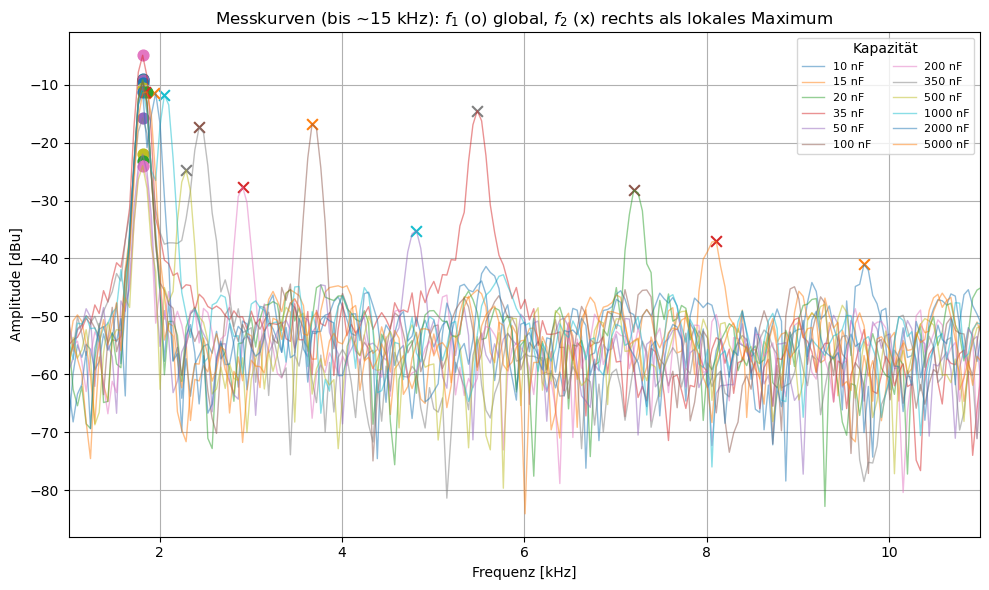


Gefundene Peaks:
 C in nF   f1_kHz   f2_kHz
      10 1.811981 9.727478
      15 1.811981 8.106232
      20 1.811981 7.200241
      35 1.811981 5.483627
      50 1.811981 4.816055
     100 1.811981 3.671646
     200 1.811981 2.908707
     350 1.811981 2.431870
     500 1.811981 2.288818
    1000 1.811981 2.050400
    2000 1.811981 1.940950
    5000 1.859665 1.839871


In [10]:
# | fig-cap: Messkurven (bis ~15 kHz) wobei $f_1$ (als Kreis o gekenntzeichnet) global, $f_2$ (als Kreuz x gekenntzeichnet) rechts als lokales Maximum

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# KONFIGURATION
# =========================
DATA_DIR = Path("./Messdaten/Aufgabe1")
ALLOWED_VALUES = [10, 15, 20, 35, 50, 100, 200, 350, 500, 1000, 2000, 5000]

CSV_SEPARATOR_CANDIDIDATES = [",", ";", "\t"]
DECIMAL_CANDIDATES = [".", ","]
ENCODING = "utf-8"

X_COLUMN_NAME = None
Y_COLUMN_NAME = None

X_LIMIT_KHZ = 15.0
FIGSIZE = (16, 6)
DPI = 150

# Heuristiken für f2-Suche
MIN_DROP_DB = 3.0      # Minimum-Abfall nach f1, damit ein Tal zählt
MIN_SEP_KHZ = 0.15     # Mindestabstand f1->f2

# Manuelle f2-Werte für problematische Kapazitäten (kHz)
F2_OVERRIDE_KHZ = {
    2000: 1.94095,
    5000: 1.839871,
}


# =========================
# HELPERS
# =========================
def extract_value_from_filename(stem: str) -> int | None:
    for v in sorted(ALLOWED_VALUES, reverse=True):
        if re.search(rf"(^|[^0-9]){v}([^0-9]|$)", stem):
            return v
    return None

def read_csv_robust(path: Path) -> pd.DataFrame:
    last_err = None
    for sep in CSV_SEPARATOR_CANDIDIDATES:
        for dec in DECIMAL_CANDIDATES:
            try:
                df = pd.read_csv(path, sep=sep, decimal=dec, encoding=ENCODING)
                if df.shape[1] >= 2:
                    return df
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Konnte CSV nicht lesen: {path.name}. Letzter Fehler: {last_err}")

def pick_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    if X_COLUMN_NAME and Y_COLUMN_NAME:
        if X_COLUMN_NAME not in df.columns or Y_COLUMN_NAME not in df.columns:
            raise ValueError(f"Spalten nicht gefunden. Vorhanden: {list(df.columns)}")
        return X_COLUMN_NAME, Y_COLUMN_NAME

    numeric_cols = []
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() > max(5, int(0.5 * len(s))):
            numeric_cols.append(col)

    if len(numeric_cols) < 2:
        raise ValueError(f"Zu wenige numerische Spalten. Vorhanden: {list(df.columns)}")

    return numeric_cols[0], numeric_cols[1]

def infer_x_units(curves):
    x_max = max(float(np.nanmax(x)) for _, x, _, _ in curves)
    if x_max > 1000:
        return "Hz", 15000.0
    else:
        return "kHz", X_LIMIT_KHZ

def amplitude_at_frequency(xw: np.ndarray, yw: np.ndarray, f: float) -> float:
    """Amplitude am nächsten Datenpunkt zu Frequenz f."""
    idx = int(np.argmin(np.abs(xw - f)))
    return float(yw[idx])

def find_f2_right_local_max(xw: np.ndarray, yw: np.ndarray, i1: int, x_unit: str):
    """
    f2 rechts von f1:
    - warte bis Signal um MIN_DROP_DB gefallen ist (Tal)
    - danach: lokale Maxima sammeln (y[i-1] < y[i] >= y[i+1])
    - nehme das höchste lokale Maximum (robuster gegen Rauschen)
    """
    if i1 >= len(yw) - 3:
        return None, None

    # Mindestabstand in Samples
    dx = np.median(np.diff(xw)) if len(xw) > 5 else 0.01
    if x_unit == "kHz":
        min_sep_samples = int(max(1, MIN_SEP_KHZ / max(dx, 1e-9)))
    else:
        min_sep_samples = int(max(1, (MIN_SEP_KHZ * 1000.0) / max(dx, 1e-9)))

    start = min(len(yw) - 1, i1 + min_sep_samples)

    y1 = yw[i1]
    valley_threshold = y1 - MIN_DROP_DB

    # Tal suchen
    valley_found = False
    valley_start = None
    for i in range(start, len(yw) - 2):
        if yw[i] < valley_threshold:
            valley_found = True
            valley_start = i
            break

    if not valley_found or valley_start is None:
        return None, None

    # lokale Maxima nach Tal
    local_max_idx = []
    for i in range(valley_start + 1, len(yw) - 1):
        if yw[i - 1] < yw[i] >= yw[i + 1]:
            local_max_idx.append(i)

    if not local_max_idx:
        return None, None

    best = max(local_max_idx, key=lambda idx: yw[idx])
    return float(xw[best]), float(yw[best])


# =========================
# MAIN
# =========================
def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Keine CSV-Dateien in {DATA_DIR.resolve()} gefunden.")

    curves = []
    for path in csv_files:
        C = extract_value_from_filename(path.stem)
        if C is None:
            continue

        df = read_csv_robust(path)
        x_col, y_col = pick_xy_columns(df)

        x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]

        if len(x) < 10:
            continue

        curves.append((C, x, y, path.name))

    if not curves:
        raise RuntimeError("Keine verwertbaren Daten. Prüfe Dateinamen/Spalten/Format.")

    curves.sort(key=lambda t: t[0])

    x_unit, x_limit = infer_x_units(curves)

    plt.figure(figsize=(10, 6))

    rows = []
    for C, x, y, fname in curves:
        m = (x >= 0) & (x <= x_limit)
        xw, yw = x[m], y[m]
        if len(xw) < 5:
            continue

        plt.plot(xw, yw, linewidth=1, alpha=0.5, label=f"{C} nF")

        # f1 globales Maximum
        i1 = int(np.argmax(yw))
        f1 = float(xw[i1])
        a1 = float(yw[i1])
        plt.scatter([f1], [a1], s=60, marker="o")

        # f2 bestimmen
        f2, a2 = find_f2_right_local_max(xw, yw, i1=i1, x_unit=x_unit)

        # Override für 2000/5000 (nur f2), Marker bleibt normal
        if x_unit == "kHz" and C in F2_OVERRIDE_KHZ:
            f2 = float(F2_OVERRIDE_KHZ[C])
            a2 = amplitude_at_frequency(xw, yw, f2)

        if f2 is not None and a2 is not None:
            plt.scatter([f2], [a2], s=60, marker="x")

        rows.append((C, f1, f2))

    plt.xlim(1, 11)
    plt.xlabel(f"Frequenz [{x_unit}]")
    plt.ylabel("Amplitude [dBu]")
    plt.title("Messkurven (bis ~15 kHz): $f_1$ (o) global, $f_2$ (x) rechts als lokales Maximum")
    plt.legend(title="Kapazität", ncols=2, fontsize=8)
    plt.tight_layout()
    plt.grid()
    plt.show()

    out = pd.DataFrame(rows, columns=["C in nF", f"f1_{x_unit}", f"f2_{x_unit}"])
    print("\nGefundene Peaks:")
    print(out.to_string(index=False))


if __name__ == "__main__":
    main()


Wenn wir die gefundenen Peaks mit den gemessenen vergleichen, stimmen sie sehr gut überein. Deshalb verwenden wir diese aus den Spektren bestimmten Resonanzfrequenzen $f_1$ und $f_2$ für die weitere Auswertung.

## Kopplung, Kopplungsgrad und Fit

Zwei identische Schwingkreise, die über einen Kopplungskondensator $C_k$ verbunden sind, bilden ein gekoppeltes System mit zwei Normalmoden. Im Spektrum erscheinen diese als zwei Resonanzfrequenzen:
- $f_1$: gleichsinnige Schwingung  
- $f_2$: gegensinnige Schwingung  

Die Kopplung führt dazu, dass die Eigenfrequenz “aufspaltet”. Je größer die Aufspaltung, desto stärker ist die Kopplung.

### Kopplungsgrad aus den Resonanzfrequenzen
Aus den beiden Resonanzfrequenzen wird der dimensionslose Kopplungsgrad $k$ berechnet mit

$$k=\left|\frac{f_2^2-f_1^2}{f_2^2+f_1^2}\right|$$

(die Formel ist äquivalent zur Version mit $\omega$, da $\omega=2\pi f$ und sich der Faktor $2\pi$ herauskürzt).  
Damit gilt: kleine Frequenzaufspaltung $\Rightarrow$ kleines $k$ (schwache Kopplung), große Aufspaltung $\Rightarrow$ großes $k$ (starke Kopplung).

### Fit-Funktion und Bestimmung von $C$
Für die Tiefpunkt-Schaltung ergibt sich theoretisch der Zusammenhang zwischen Kopplungsgrad und Kopplungskapazität:

$$k(C_k)=\frac{C}{C+C_k}$$

Hier ist $C_k$ der jeweils eingesetzte Kopplungskondensator (Messgröße auf der x-Achse) und $C$ die gesuchte Kapazität des Schwingkreises.  
Durch einen nichtlinearen Fit dieser Funktion an die gemessenen $k$-Werte wird $C$ als Fitparameter bestimmt.

In unserem jetzt kommenden Fit haben wir den Wert $C =149.393698 \text{nF}$ bestimmt.


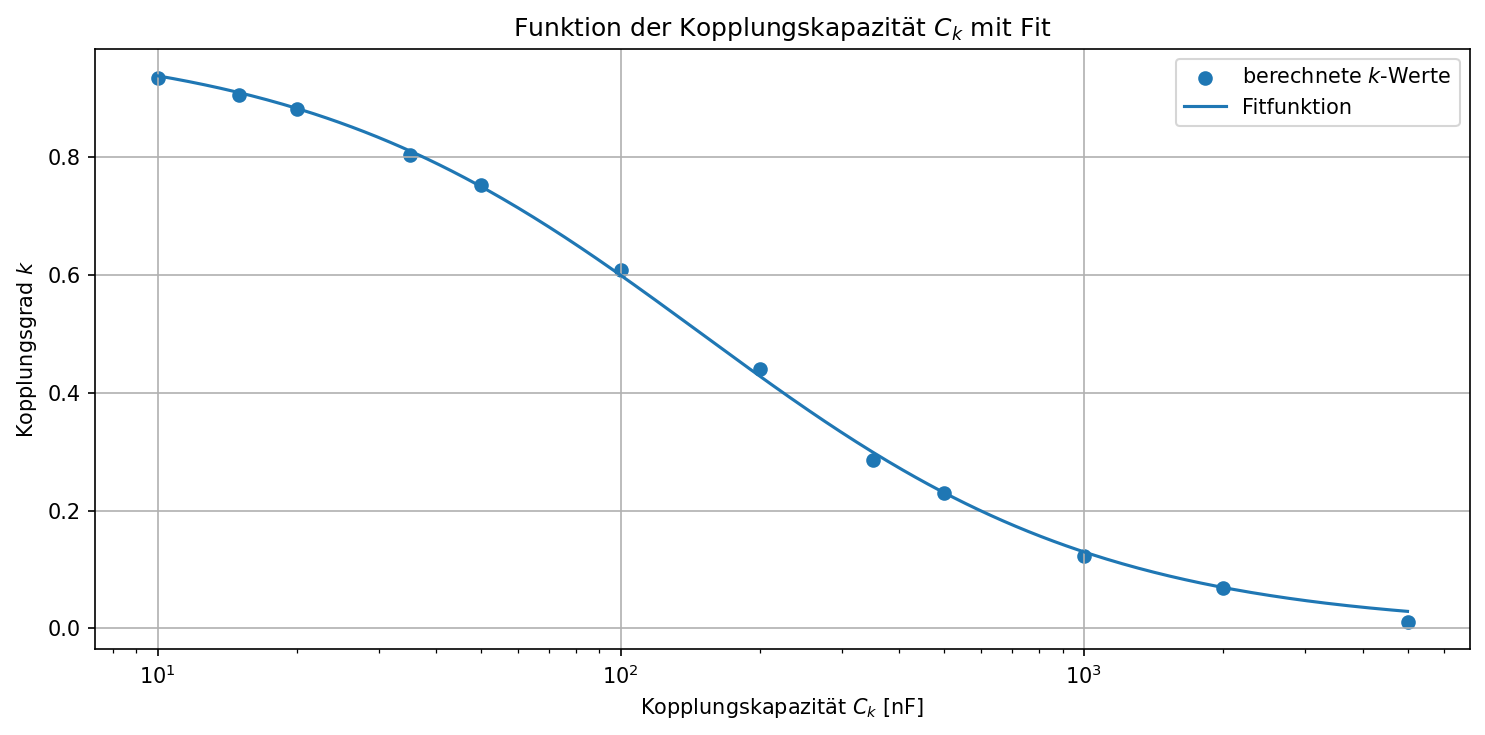

C = 149.393698 nF


In [1]:
# | fig-cap: Kopplungsgrad $k$ also Funktion der Kopplungskapazität $C_k$ mit Fit mit logarithmischer Auftragung

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# 1) DATEN (deine Peaks)
# =========================
data = [
    (10,   1.811981, 9.727478),
    (15,   1.811981, 8.106232),
    (20,   1.811981, 7.200241),
    (35,   1.811981, 5.483627),
    (50,   1.811981, 4.816055),
    (100,  1.811981, 3.671646),
    (200,  1.811981, 2.908707),
    (350,  1.811981, 2.431870),
    (500,  1.811981, 2.288818),
    (1000, 1.811981, 2.050400),
    (2000, 1.811981, 1.940950),
    (5000, 1.859665, 1.839871),
]
df = pd.DataFrame(data, columns=["Ck_nF", "f1_kHz", "f2_kHz"])

# =========================
# 2) k aus Frequenzen (Definition aus Skript)
# =========================
f_low  = np.minimum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))
f_high = np.maximum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))

k = (f_high**2 - f_low**2) / (f_high**2 + f_low**2)

df["f_low_kHz"] = f_low
df["f_high_kHz"] = f_high
df["k"] = k

# =========================
# 3) FIT (Aufgabe 1, Tiefpunkt):
#     k(Ck) = C / (C + Ck)
#     Fitparameter: C
# =========================
def k_tiefpunkt(Ck, C):
    return C / (C + Ck)

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

Ck = df["Ck_nF"].to_numpy(float)   # x: Kopplungskondensator
y  = df["k"].to_numpy(float)       # y: Kopplungsgrad

# Startwert: irgendwo in der Größenordnung der "Knickstelle"
p0 = [150.0]
bounds = ([1e-9], [np.inf])

popt, pcov = curve_fit(k_tiefpunkt, Ck, y, p0=p0, bounds=bounds, maxfev=20000)
C_fit = float(popt[0])

y_hat = k_tiefpunkt(Ck, C_fit)
r2 = r2_score(y, y_hat)

# =========================
# 4) PLOT
# =========================
Ck_plot = np.logspace(np.log10(Ck.min()), np.log10(Ck.max()), 400)
k_plot  = k_tiefpunkt(Ck_plot, C_fit)

plt.figure(figsize=(10, 5), dpi=150)
plt.scatter(Ck, y, label="berechnete $k$-Werte")
plt.plot(Ck_plot, k_plot, label=f"Fitfunktion")
plt.xscale("log")
plt.xlabel("Kopplungskapazität $C_k$ [nF]")
plt.ylabel("Kopplungsgrad $k$")
plt.title("Funktion der Kopplungskapazität $C_k$ mit Fit")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(f"C = {C_fit:.6f} nF")


# Aufgabe 2a

Bei dieser Aufgabe sollten, die Frequenzspektren bei der Hochpunktschaltung mit verschiedenen Kopplungskapazitäten gemessen werden. Aus den gemessenen Resonanzfrequenzen $f_1$ und $f_2$ wird der Kopplungsgrad bestimmt und die Kopplungskapazität $C$ durch Anpassung an die theoretische Funktion ermittelt. Der Versuchs aufbau war folgender:

![Hochpunkt-Schaltung kapazitiv gekoppelter Schwingkreise, Schaltplan für Aufgabe 2, entnommen aus dem E17 Dokument von zugehörigen Moodelkurs](./Grafiken/Aufgabe2.png)

Die Resonanzfrequenzen ergibt sich aus den zwei Formeln
$$f_1 = \frac{1}{2\pi\sqrt{LC}}$$

$$f_2 = \frac{1}{2\pi\sqrt{L(C+C_K)}}$$

wobei $f_1$ unabhängig von $C_K$ ist und $f_2$ wiederum nicht.

Der Kopplungsgrad wird aus den gemessenen Frequenzen berechnet und gegen die Kopplungskapazität aufgetragen. Durch Anpassung der Funktion $k_C = \frac{C_K}{C+C_K}$ erhalten wir die gesuchte Kapazität $C$.

[]

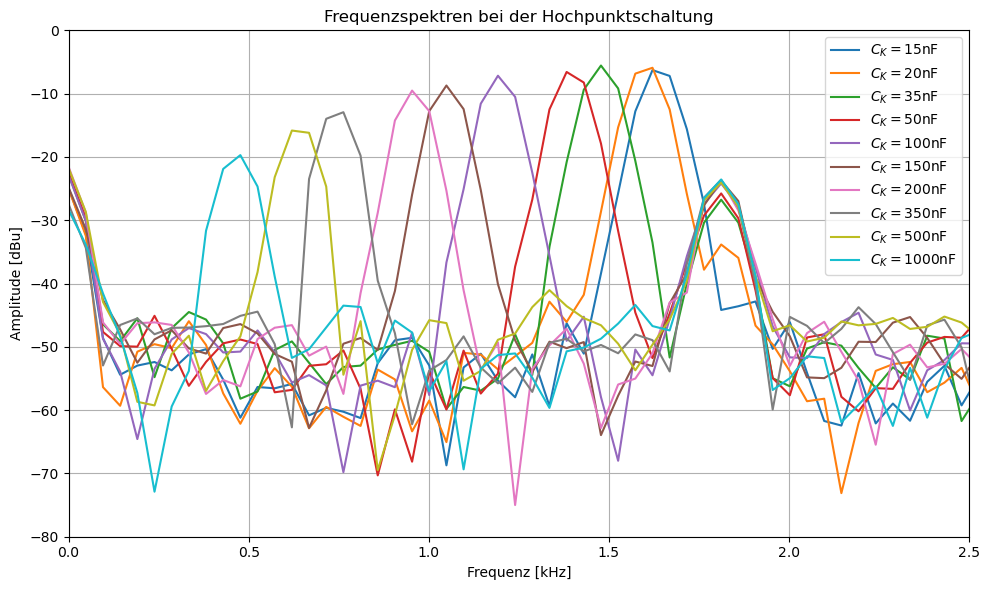

In [5]:
# fig-cap: Frequenzspektren der Hochpunktschaltung, wobei das jeweils rechte Maximum bei $f_0$ liegt für alle Messungen.

import pandas as pd
import matplotlib.pyplot as plt

werte = [[15, 1.84, 1.63],
[20, 1.82, 1.62],
[35, 1.82, 1.48],
[50, 1.82, 1.39],
[100, 1.81, 1.20],
[150, 1.81, 1.05],
[200, 1.81, 0.96],
[350, 1.81, 0.77],
[500, 1.81, 0.64],
[1000, 1.81, 0.48]]

capacity = [[1, 15], [2, 20], [3, 35], [4, 50], [5, 100], [6, 150], [7, 200], [8, 350], [9, 500], [10, 1000]]

plt.figure(figsize=(10, 6))

for i in werte:
    df = pd.read_csv(f"./Messdaten/Aufgabe2/Gegensinnig/E17_Aufgabe2_Kapazitaet_{i[0]}nF.csv")

    plt.plot(df["Frequency[kHz]"], df["Channel[dBu]"], label=f"$C_K = {i[0]}$nF")

plt.xlim(0, 2.5)
plt.ylim(-80, 0)
plt.grid()
plt.title("Frequenzspektren bei der Hochpunktschaltung")
plt.xlabel("Frequenz [kHz]")
plt.ylabel("Amplitude [dBu]")
plt.tight_layout()
plt.legend()
plt.plot()

## Fit des Kopplungsgrad

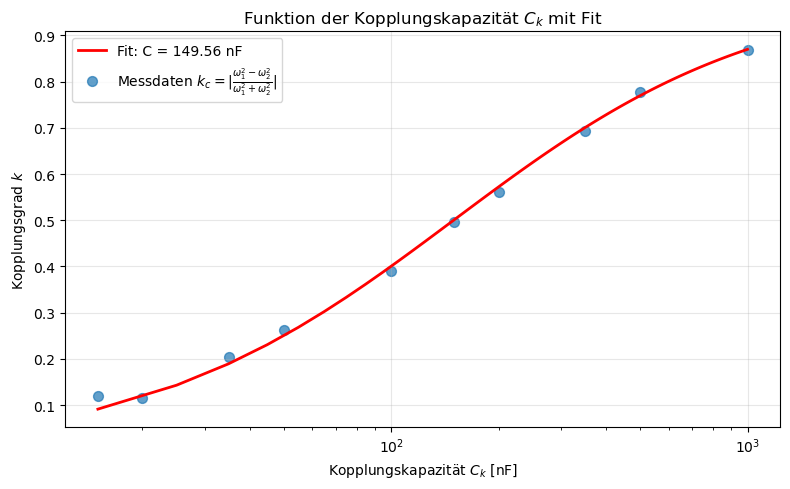

C = 149.560149 nF


In [8]:
# | fig-cap: Funktion der Kopplungskapazität $C_k$ mit Fit, mit $C \approx 149.6$ nF

from scipy.optimize import curve_fit
import numpy as np

x = []
y = []

for i in werte:
    y.append(i[0])
    omega1 = 2* np.pi * i[1]
    omega2 = 2* np.pi * i[2]
    x.append(np.abs((omega1**2 - omega2**2)/(omega1**2 + omega2**2)))

# Define the fitting function: k = C_k / (C + C_k)
# C_k is the independent variable (x-axis), C is the parameter to fit
def coupling_degree(C_k, C):
    return C_k / (C + C_k)

p0 = [50.0]
bounds = ([1e-9], [np.inf])

popt, pcov = curve_fit(coupling_degree, y, x, p0=p0, bounds=bounds, maxfev=20000)
C_fit = float(popt[0])

# Plot the fit
y_fit = np.linspace(min(y), max(y), 100)
x_fit = coupling_degree(y_fit, C_fit)
plt.figure(figsize=(8, 5))
plt.plot(y_fit, x_fit, 'r-', label=f'Fit: C = {C_fit:.2f} nF', linewidth=2)

plt.scatter(y, x, s=50, alpha=0.7, label='Messdaten $k_c = \\vert \\frac{\\omega_1^2 - \\omega_2^2}{\\omega_1^2 + \\omega_2^2} \\vert$')
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("Kopplungskapazität $C_k$ [nF]")
plt.ylabel("Kopplungsgrad $k$")
plt.title("Funktion der Kopplungskapazität $C_k$ mit Fit")
plt.legend()
plt.tight_layout()
plt.show()

print(f"C = {C_fit:.6f} nF")

Mit $C \approx 149.6$ nF kommen wir auf einen sehr ähnlichen Wert wie in Aufgabe 1, mit $C = 149.4$ nF. Die leichte ABweichung, kann auf Messfehler zurückgeführt werden oder auf Schltkreiskomponenten (Wiederstände oder anderes) mit eigneer Kapazität

# Aufgabe 2b
Indem ein Schalter in der Hochpunktschaltung überbrückt wird, wird die Spannung nur auf einer Seite angelegt. Dadurch können wir bei einer Einstellung von $C_K = 50$ nF die Schwebungsschwingung und das entsprechende Frequenzspektrum aufnehmen.

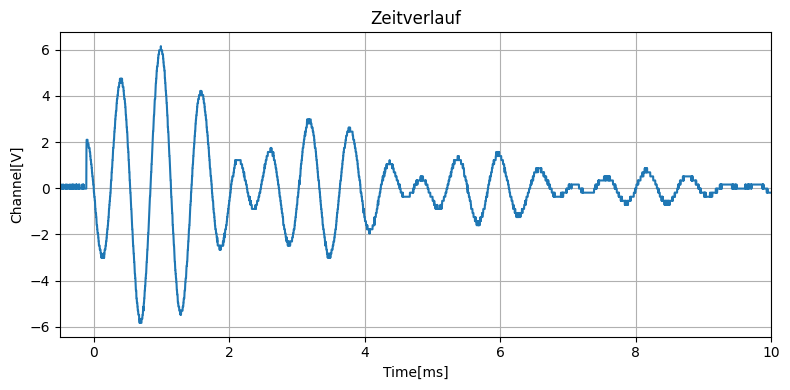

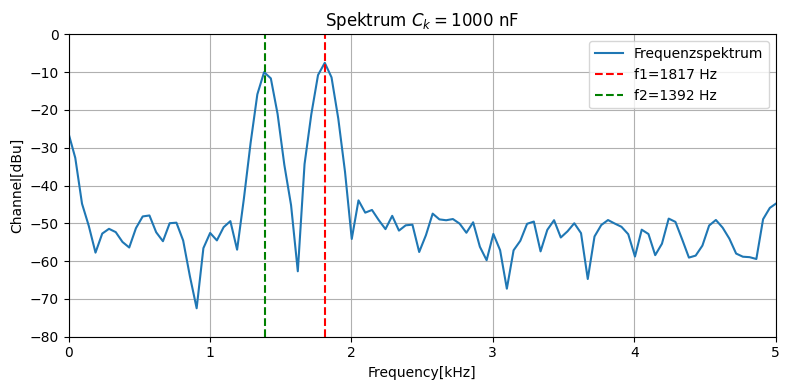

In [25]:
# | fig-cap:
# |     - Schwebungsschwingung bei der Hochpunktschaltung für $C_K = 50$ nF
# |     - Frequenzspektrum, mit zwei ausgeprägten Maxima, der Schwebungsschwingung bei der Hochpunktschaltung für $C_K = 50$ nF

f1 = 1.817e3 #Hz
f2 = 1.392e3 #Hz

spektrum = pd.read_csv(f"./Messdaten/Aufgabe2/Schwebung/E17_Aufgabe2b_Kapazitaet_50nF_Spektrum.csv")
zeit = pd.read_csv(f"./Messdaten/Aufgabe2/Schwebung/E17_Aufgabe2b_Kapazitaet_50nF_Zeit.csv")


# Time signal
plt.figure(figsize=(8,4))
xcol_t, ycol_t = zeit.columns[0], zeit.columns[1]
#plt.subplot(2,1,2)
plt.plot(zeit[xcol_t], zeit[ycol_t])
plt.grid()
plt.xlabel(xcol_t)
plt.ylabel(ycol_t)
plt.title("Zeitverlauf")
plt.xlim(-0.5, 10)
plt.tight_layout()
plt.show()

# plot spectrum and time for current i (uses spektrum and zeit already read)
plt.figure(figsize=(8,4))

# Spectrum
xcol_s, ycol_s = spektrum.columns[0], spektrum.columns[1]
#plt.subplot(2,1,1)
plt.plot(spektrum[xcol_s], spektrum[ycol_s], label="Frequenzspektrum")
# convert marker frequencies to axis units if needed
f1_plot, f2_plot = f1, f2
if 'khz' in xcol_s.lower():
    f1_plot, f2_plot = f1/1e3, f2/1e3
plt.axvline(f1_plot, color='r', linestyle='--', label=f'f1={f1:.0f} Hz')
plt.axvline(f2_plot, color='g', linestyle='--', label=f'f2={f2:.0f} Hz')
plt.legend()
plt.grid()
plt.xlabel(xcol_s)
plt.ylabel(ycol_s)
plt.xlim(0, 5)
plt.ylim(-80, 0)
plt.title(f"Spektrum $C_k={i[0]}$ nF")
plt.tight_layout()
plt.show()



Wir erhalten die Frequenzen $f_1 = 1.871 \pm 0.10$ kHz und $f_2 = 1.392 \pm 0.10$ kHz. Die Periodendauer, erhält man aus einer Frequenz durch $T = \frac{1}{f} = \frac{2\pi}{\omega}$, sodass mit $f_2 = f_0$ und $f_S = f_2 - f_1$ wir die Periodendauer der Schwebung finden:

$$T_S = \frac{1}{f_S} = \frac{1}{f_2 - f_1}$$

Aus den gemessenen Frequenzen erhalten wir die Schwebungsfrequenz:
$$f_S = f_2 - f_1 = 1392 - 1817 = -425 \text{ Hz}$$

Somit beträgt die Schwebungsperiode:
$$T_S = \frac{1}{|f_S|} = \frac{1}{425} \approx 2.35 \text{ ms}$$

Aus der Schwebungsschwingung im Zeitverlauf können wir experimentell $T_S \approx 2.35$ ms bestätigen. Mit einem kurzen Vergleich zu der Aufgabe 2a stimmen die Werte gut zueinander.


# Aufgabe 3

In Aufgabe 3 ist dass Ziel, für zwei induktiv gekoppelte LC-Schwingkreise soll der Kopplungsgrad $k_L$ in Abhängigkeit vom Spulenabstand $d$ bestimmt werden. Dazu werden die Resonanzfrequenzen $f_+$ und $f_-$ aus den FFT-Spektren entnommen. Anschließend wird aus $k_L$ die Gegeninduktivität $M$ berechnet und $M(d)$ mit dem theoretischen Maxwell-Ausdruck verglichen. Wir haben den folgenden Schaltkreis für die Aufgabe genutzt:

![Abbildung der aufgebauten Schaltung, für die Aufgabe 3. Entnommen aus der Experimentierbeschreibung im Moodlekurs](./Aufgabe3.png)

## Messprinzip
Bei induktiver Kopplung beeinflusst das Magnetfeld der einen Spule die andere. Mathematisch führt das auf gekoppelte Differentialgleichungen, die durch Bildung von

$$
I_+ = I_A + I_B,\quad I_- = I_A - I_B
$$

entkoppelt werden. Dadurch erhält man zwei Eigenmoden mit effektiven Induktivitäten $L+M$ (gleichsinnig) und $L-M$ (gegensinnig). Die zugehörigen Kreisfrequenzen lauten:

$$
\omega_+ = \frac{1}{\sqrt{C(L+M)}},\qquad
\omega_- = \frac{1}{\sqrt{C(L-M)}}
$$

Damit ist $\omega_+ < \omega_-$ und im FFT-Spektrum erscheinen zwei Resonanzpeaks bei $f_+ = \omega_+/(2\pi)$ und $f_- = \omega_-/(2\pi)$


## Bestimmung der Frequenzen aus den Spektren
Für jeden gemessenen Abstand $d$:

1. FFT-Spektrum aufnehmen und in einer gemeinsamen Abbildung darstellen (so wie bei Aufgabe 1).
2. Die beiden Resonanzfrequenzen bestimmen:
   - $f_+$: der kleinere Peak (gleichsinnige Mode),
   - $f_-$: der größere Peak (gegensinnige Mode).
3. Zusätzlich einmal die ungekoppelte Eigenfrequenz $f_0$ messen. Dafür haben wir bei uns $f_0 = 2.843 kHz$ herausbekommen.

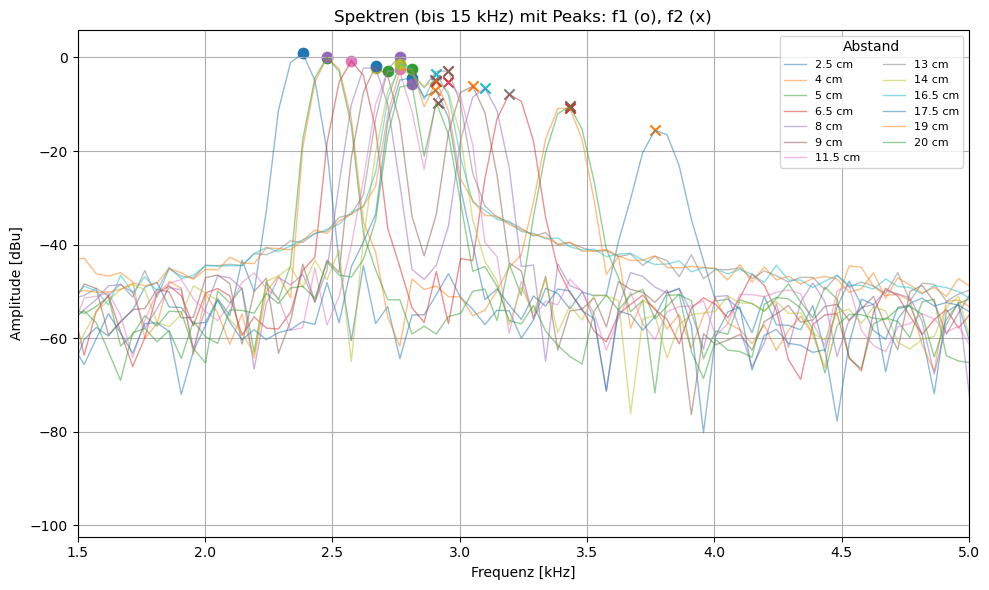


Gefundene Peaks:
 d_cm   f-_kHz   f+_kHz
  2.5 2.384186 3.767014
  4.0 2.479553 3.433228
  5.0 2.479553 3.433228
  6.5 2.574921 3.194809
  8.0 2.670288 3.099442
  9.0 2.670288 3.051758
 11.5 2.717972 2.956390
 13.0 2.765656 2.956390
 14.0 2.765656 2.901984
 16.5 2.765656 2.906540
 17.5 2.813339 2.902760
 19.0 2.813339 2.908210
 20.0 2.813339 2.914901


In [3]:
# | fig-cap: Spektren (bis 15 kHz) mit Peaks wobei f1 (Markiert mit dem Kreis o), f2 (Markiert mit dem Kreuz x)

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# KONFIGURATION
# =========================
DATA_DIR = Path("./Messdaten/Aufgabe_3")
ENCODING = "utf-8"
CSV_SEPARATOR_CANDIDATES = [",", ";", "\t"]
DECIMAL_CANDIDATES = [".", ","]

X_COLUMN_NAME = None
Y_COLUMN_NAME = None

X_LIMIT_KHZ = 15.0
FIGSIZE = (16, 6)
DPI = 150

MIN_DROP_DB = 3.0
MIN_SEP_KHZ = 0.15

# --- Override f2 (kHz) für Abstände mit falschen Peaks ---
# Werte aus deiner Mess-Tabelle:
F2_OVERRIDE_KHZ = {
    14.0:  2.901984,
    16.5:  2.90654,
    17.5:  2.90276,
    19.0:  2.90821,
    20.0:  2.914901,
}
# (Falls später noch was auffällt: einfach hier ergänzen)


# =========================
# HELPERS
# =========================
def read_csv_robust(path: Path) -> pd.DataFrame:
    last_err = None
    for sep in CSV_SEPARATOR_CANDIDATES:
        for dec in DECIMAL_CANDIDATES:
            try:
                df = pd.read_csv(path, sep=sep, decimal=dec, encoding=ENCODING)
                if df.shape[1] >= 2:
                    return df
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Konnte CSV nicht lesen: {path.name}. Letzter Fehler: {last_err}")

def pick_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    if X_COLUMN_NAME and Y_COLUMN_NAME:
        if X_COLUMN_NAME not in df.columns or Y_COLUMN_NAME not in df.columns:
            raise ValueError(f"Spalten nicht gefunden. Vorhanden: {list(df.columns)}")
        return X_COLUMN_NAME, Y_COLUMN_NAME

    numeric_cols = []
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() > max(5, int(0.5 * len(s))):
            numeric_cols.append(col)

    if len(numeric_cols) < 2:
        raise ValueError(f"Zu wenige numerische Spalten. Vorhanden: {list(df.columns)}")
    return numeric_cols[0], numeric_cols[1]

def infer_x_units(curves):
    x_max = max(float(np.nanmax(x)) for _, x, _, _ in curves)
    if x_max > 1000:
        return "Hz", 15000.0
    return "kHz", X_LIMIT_KHZ

def extract_distance_cm(filename: str) -> float | None:
    m = re.search(r"Abstand[_\- ](\d+(?:[,_]\d+)?)\s*cm", filename, flags=re.IGNORECASE)
    if not m:
        return None
    s = m.group(1).replace(",", ".").replace("_", ".")
    return float(s)

def amplitude_at_frequency(xw: np.ndarray, yw: np.ndarray, f: float) -> float:
    idx = int(np.argmin(np.abs(xw - f)))
    return float(yw[idx])

def find_f2_right_local_max(xw: np.ndarray, yw: np.ndarray, i1: int, x_unit: str):
    if i1 >= len(yw) - 3:
        return None, None

    dx = np.median(np.diff(xw)) if len(xw) > 5 else 0.01
    if x_unit == "kHz":
        min_sep_samples = int(max(1, MIN_SEP_KHZ / max(dx, 1e-9)))
    else:
        min_sep_samples = int(max(1, (MIN_SEP_KHZ * 1000.0) / max(dx, 1e-9)))

    start = min(len(yw) - 1, i1 + min_sep_samples)

    y1 = yw[i1]
    valley_threshold = y1 - MIN_DROP_DB

    valley_start = None
    for i in range(start, len(yw) - 2):
        if yw[i] < valley_threshold:
            valley_start = i
            break
    if valley_start is None:
        return None, None

    local_max_idx = []
    for i in range(valley_start + 1, len(yw) - 1):
        if yw[i - 1] < yw[i] >= yw[i + 1]:
            local_max_idx.append(i)
    if not local_max_idx:
        return None, None

    best = max(local_max_idx, key=lambda idx: yw[idx])
    return float(xw[best]), float(yw[best])


# =========================
# MAIN
# =========================
def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Keine CSV-Dateien in {DATA_DIR.resolve()} gefunden.")

    curves = []  # (d_cm, x, y, filename)
    for path in csv_files:
        d = extract_distance_cm(path.name)
        if d is None:
            continue

        df = read_csv_robust(path)
        x_col, y_col = pick_xy_columns(df)

        x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 10:
            continue

        curves.append((d, x, y, path.name))

    if not curves:
        raise RuntimeError("Keine Dateien verarbeitet. Prüfe Dateinamen (Abstand_xcm) und Spalten.")

    curves.sort(key=lambda t: t[0])

    x_unit, x_limit = infer_x_units(curves)

    plt.figure(figsize=(10, 6))

    rows = []
    for d, x, y, fname in curves:
        m = (x >= 0) & (x <= x_limit)
        xw, yw = x[m], y[m]
        if len(xw) < 5:
            continue

        plt.plot(xw, yw, linewidth=1, alpha=0.5, label=f"{d:g} cm")

        # f1 = globales Maximum
        i1 = int(np.argmax(yw))
        f1 = float(xw[i1])
        a1 = float(yw[i1])
        plt.scatter([f1], [a1], s=55, marker="o")

        # f2 = automatisch
        f2, a2 = find_f2_right_local_max(xw, yw, i1=i1, x_unit=x_unit)

        # f2 Override für problematische Abstände (nur wenn x in kHz)
        d_key = round(float(d), 1)
        if x_unit == "kHz" and d_key in F2_OVERRIDE_KHZ:
            f2 = float(F2_OVERRIDE_KHZ[d_key])
            a2 = amplitude_at_frequency(xw, yw, f2)

        if f2 is not None:
            plt.scatter([f2], [a2], s=55, marker="x")

        rows.append((d, f1, f2))

    plt.xlim(1.5, 5)
    plt.xlabel(f"Frequenz [{x_unit}]")
    plt.ylabel("Amplitude [dBu]")
    plt.title("Spektren (bis 15 kHz) mit Peaks: f1 (o), f2 (x)")
    plt.legend(title="Abstand", ncols=2, fontsize=8)
    plt.tight_layout()
    plt.grid()
    plt.show()

    out = pd.DataFrame(rows, columns=["d_cm", f"f-_{x_unit}", f"f+_{x_unit}"]).sort_values("d_cm")
    print("\nGefundene Peaks:")
    print(out.to_string(index=False))


if __name__ == "__main__":
    main()


### Kopplungsgrad $k_L(d)$ aus den Peaks
Aus jedem Spektrum werden die beiden Resonanzfrequenzen bestimmt. Dabei setzen wir
$f_+ = \min(f_1,f_2)$ und $f_-=\max(f_1,f_2)$. Der Kopplungsgrad ist definiert als

$$
k=\left|\frac{\omega_1^2-\omega_2^2}{\omega_1^2+\omega_2^2}\right|
$$

Mit $\omega=2\pi f$ ergibt sich direkt

$$
k_L(d)=\frac{f_-^2-f_+^2}{f_-^2+f_+^2}
$$

Alternativ kann man $k_L$ auch über die Skript-Beziehung interpretieren:

$$
\omega_\pm=\frac{\omega_0}{\sqrt{1\pm k_L}},\qquad k_L=\frac{M}{L}
$$

### Gegeninduktivität $M(d)$ berechnen
Aus $k_L=\frac{M}{L}$ folgt

$$
M(d)=k_L(d)\,L
$$

Die Induktivität $L$ bestimmen wir aus der ungekoppelten Eigenfrequenz $f_0$:

$$
L=\frac{1}{(2\pi f_0)^2\,C}
$$

### Theorievergleich (Maxwell) und Fit
Die Aufgabe fordert, $M(d)$ als Funktion von $d$ darzustellen und mit dem theoretischen Ausdruck zu vergleichen.
Dazu fitten wir die Messwerte $M(d)$ mit dem Maxwell-Ausdruck für zwei koaxiale Ringe:

$$
M(d)=\frac{2\mu_0 a}{\kappa}\left[\left(1-\frac{1}{2}\kappa^2\right)K(\kappa)-E(\kappa)\right],
\qquad
\kappa=\left(1+\left(\frac{d}{2a}\right)^2\right)^{-1/2}
$$


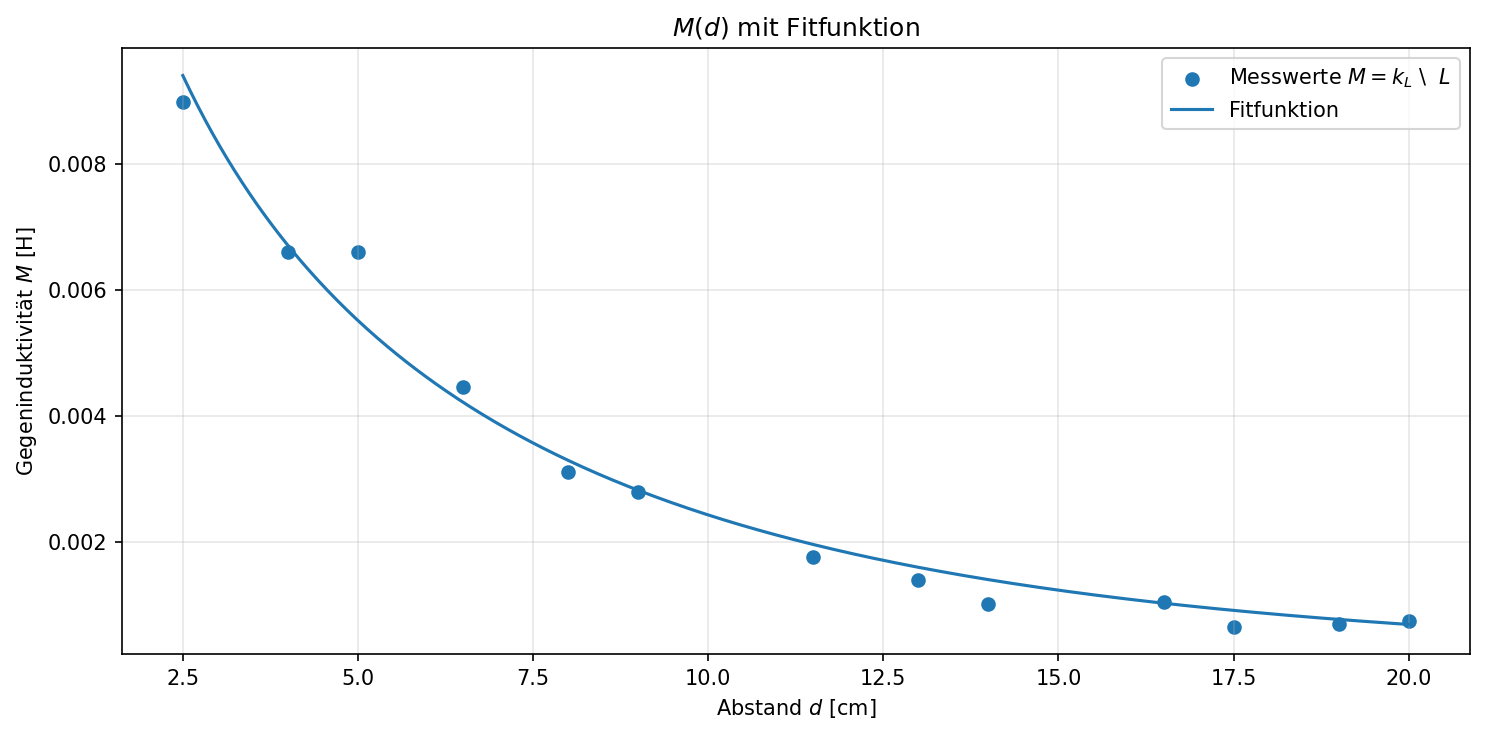

In [2]:
# | fig-cap: Gegeninduktivität $M(d)$ mit hergeleiteten Fitfunktion

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import ellipk, ellipe

# =========================================================
# 1) EINGABE: Peaks (Aufgabe 3)
# =========================================================
data = [
    (2.5,  2.384186, 3.767014),
    (4.0,  2.479553, 3.433228),
    (5.0,  2.479553, 3.433228),
    (6.5,  2.574921, 3.194809),
    (8.0,  2.670288, 3.099442),
    (9.0,  2.670288, 3.051758),
    (11.5, 2.717972, 2.956390),
    (13.0, 2.765656, 2.956390),
    (14.0, 2.765656, 2.901984),
    (16.5, 2.765656, 2.906540),
    (17.5, 2.813339, 2.902760),
    (19.0, 2.813339, 2.908210),
    (20.0, 2.813339, 2.914901),
]
df = pd.DataFrame(data, columns=["d_cm", "f1_kHz", "f2_kHz"])

# Ungekoppelte Eigenfrequenz
f0_kHz = 2.843

# Kapazität aus dem Aufbau eintragen (sonst bleibt M(d) unbestimmt)
# Beispiel: 100 nF -> 100e-9
C_F = 149.393698e-9  # <-- HIER setzen, wenn du M(d) wirklich plotten willst

# =========================================================
# 2) k_L aus Peaks
# =========================================================
f_plus = np.minimum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))
f_minus = np.maximum(df["f1_kHz"].to_numpy(float), df["f2_kHz"].to_numpy(float))

kL = (f_minus**2 - f_plus**2) / (f_minus**2 + f_plus**2)
df["kL"] = kL

# =========================================================
# 3) L und M(d) (nur wenn C_F gesetzt)
# =========================================================
if C_F is None:
    raise ValueError("Bitte C_F (Kapazität aus dem Aufbau) setzen, damit M(d) berechnet und gefittet werden kann.")

f0_Hz = f0_kHz * 1e3
L_H = 1.0 / ((2.0 * np.pi * f0_Hz) ** 2 * C_F)

M_meas = kL * L_H  # M(d) = kL(d)*L

# =========================================================
# 4) Maxwell-Modell: M(d) = scale * M_ring(d,a)
# =========================================================
mu0 = 4.0 * np.pi * 1e-7

def M_ring(d_m, a_m):
    kappa = 1.0 / np.sqrt(1.0 + (d_m / (2.0 * a_m))**2)
    m = kappa**2
    K = ellipk(m)
    E = ellipe(m)
    return 2.0 * mu0 * a_m / kappa * ((1.0 - 0.5 * kappa**2) * K - E)

def M_model(d_m, scale, a_m):
    return scale * M_ring(d_m, a_m)

d_m = df["d_cm"].to_numpy(float) / 100.0

# Startwerte: scale ~ 1, a ~ 8 cm
p0 = [1.0, 0.08]
bounds = ([0.0, 1e-4], [np.inf, 1.0])

popt, _ = curve_fit(M_model, d_m, M_meas, p0=p0, bounds=bounds, maxfev=20000)
scale_fit, a_fit = popt

# =========================================================
# 5) Plot (nur Grafik, keine Tabellen-Prints)
# =========================================================
d_plot = np.linspace(d_m.min(), d_m.max(), 500)
M_plot = M_model(d_plot, *popt)

plt.figure(figsize=(10, 5), dpi=150)
plt.scatter(df["d_cm"], M_meas, label="Messwerte $M=k_L$ \\  $L$")
plt.plot(d_plot * 100.0, M_plot, label=f"Fitfunktion")
plt.xlabel("Abstand $d$ [cm]")
plt.ylabel("Gegeninduktivität $M$ [H]")
plt.title("$M(d)$ mit Fitfunktion")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# print(f"\n{'='*60}")
# print(f"FITPARAMETER")
# print(f"{'='*60}")
# print(f"Spulenradius a = {a_fit*100:.2f} cm = {a_fit:.4f} m")
# print(f"{'='*60}\n")



# Fehleranalyse für Aufgabe 1 bis 3

Die Messungen sind mit verschiedenen systematischen und zufälligen Fehlern behaftet. Die Oszilloskop-Amplitudenmessung weist eine Genauigkeit von etwa $\pm3$ % auf, während die FFT-Frequenzauflösung Fehler von $\pm1$–$5$ Hz verursacht. Die Abstandsmessung hat eine Unsicherheit von $\pm0.5$ mm. Bei den Schaltungskomponenten sind die wichtigsten Fehlerquellen die Spulenverluste ($5–20 \Omega$), die Kapazitäts-Toleranz von $\pm5$ % und parasitäre Effekte. Zufällige Fehler entstehen durch thermische Drift ($0.1$–$0.5$ % Frequenzversatz), Umgebungsmagnete und Kontaktwiderstände.

Für Aufgabe 1 und 2 liegt der Fehler der Resonanzfrequenz bei etwa $\pm50$ Hz aus der FFT-Auflösung. Bei Aufgabe 3 propagiert sich der Fehler aus $f_+$ und $f_-$ in den Kopplungsgrad $k_L$ fort, und die Spulenpositionierung führt zu zusätzlichen Unsicherheiten von $5$–$10$ % in $M(d)$. Das Maxwell-Modell weicht um $3$–$8$ % von der Realität ab. Zur Fehlerminderung sollten Mehrfachmessungen gemittelt, die Temperatur stabilisiert und die Spulen sorgfältig koaxial justiert werden.
